 LOADING DATA
=============================

Load CSV files using pandas
- Using read_csv() to import datasets
- Basic data exploration with:
  - head() - view first 5 rows
  - info() - get data types and non-null counts
  - shape - check rows and columns

 <!-- Loading Data with Pandas 📥

 Load Titanic dataset

 -- Basic data exploration with:
  - head() - view first 5 rows
  - info() - get data types and non-null counts
  - shape - check rows and columns  -->

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Titanic.csv")
print(df)
df.head()
df.info()

df.shape

                                           PassengerId Survived Pclass  \
0                                                    1        0      3   
1                                                    2        1      1   
2                                                    3        1      3   
3                                                    4        1      1   
4                                                    5        0      3   
...                                                ...      ...    ...   
1780                                               888        1      1   
1781                                               889        0      3   
1782                                               890        1      1   
1783                                               891        0      3   
1784  >>>>>>> dd42941beae8f0212fbd4d9f7d68ca6e0a597537      NaN    NaN   

                                                   Name     Sex  Age SibSp  \
0                               B

(1785, 12)

In [4]:

df.isnull().sum()

PassengerId       0
Survived          2
Pclass            2
Name              2
Sex               2
Age             356
SibSp             2
Parch             2
Ticket            2
Fare              2
Cabin          1376
Embarked          6
dtype: int64

In [5]:
# STEP 1: FIND MISSING VALUES 🔍

df.isnull().sum()

PassengerId       0
Survived          2
Pclass            2
Name              2
Sex               2
Age             356
SibSp             2
Parch             2
Ticket            2
Fare              2
Cabin          1376
Embarked          6
dtype: int64

In [6]:
# Now let us calulate the damage % (percentage)

(df.isnull().sum() / len(df)) * 100

PassengerId     0.000000
Survived        0.112045
Pclass          0.112045
Name            0.112045
Sex             0.112045
Age            19.943978
SibSp           0.112045
Parch           0.112045
Ticket          0.112045
Fare            0.112045
Cabin          77.086835
Embarked        0.336134
dtype: float64

THE DROP DECISION (Cabin)

">50% MISSING = DROP it 🗑️"

In [7]:
# Cabin is 77% missing - basically useless

df.drop('Cabin', axis=1, inplace=True)
print("Cabin column dropped ☠️")

Cabin column dropped ☠️


In [8]:
# THE FILL DECISION (Age & Embarked)

# Age is 20% missing - fill with MEDIAN

# convert Age column to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Embarked is 0.3% missing - fill with MODE

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\dell 5400\AppData\Local\Temp\ipykernel_22204\3855271401.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
df.dtypes
print(df['Age'].dtype)
print(df['Age'].head())

float64
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64


In [10]:
df.dropna(inplace=True)

 FILL: MEDIAN for numbers, MODE for categories ✅
 
 THE SATISFYING FINISH (Cleaned Data)

In [11]:

df.isnull().sum().sum()


np.int64(0)

"0 MISSING VALUES 🎉"

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 0 to 1783
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1428 non-null   object 
 1   Survived     1428 non-null   object 
 2   Pclass       1428 non-null   object 
 3   Name         1428 non-null   object 
 4   Sex          1428 non-null   object 
 5   Age          1428 non-null   float64
 6   SibSp        1428 non-null   object 
 7   Parch        1428 non-null   object 
 8   Ticket       1428 non-null   object 
 9   Fare         1428 non-null   object 
 10  Embarked     1428 non-null   object 
dtypes: float64(1), object(10)
memory usage: 133.9+ KB


In [13]:
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
df['SibSp'] = pd.to_numeric(df['SibSp'], errors='coerce')
df['Parch'] = pd.to_numeric(df['Parch'], errors='coerce')

Feature Engineering Steps
=============================

In [14]:

# Ensure numeric columns are numeric


df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
df['SibSp'] = pd.to_numeric(df['SibSp'], errors='coerce')
df['Parch'] = pd.to_numeric(df['Parch'], errors='coerce')

# Fill missing values


df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# 1. Family Size

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Title Extraction

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3. Age Groups

bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 4. IsAlone Flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 5. Fare Groups
df['FareGroup'] = pd.qcut(df['Fare'], 4, labels=['Low','Medium','High','Very High'])

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


C:\Users\dell 5400\AppData\Local\Temp\ipykernel_22204\1319222491.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\dell 5400\AppData\Local\Temp\ipykernel_22204\1319222491.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [47]:
# showing the total no. of missing values in the dataset
df.isnull().sum()

# showing the percentage of missing data
(df.isnull().sum() / len(df)) * 100


# Age is 20% missing - fill with MEDIAN
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked is 0.2% missing - fill with MODE
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.isnull().sum().sum() # our dataset is clean now !!

# Create Family Size from SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Create IsAlone flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df.head())




  PassengerId Survived Pclass  \
0           1        0      3   
1           2        1      1   
2           3        1      3   
3           4        1      1   
4           5        0      3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize Title     AgeGroup  \
0      0         A/5 21171   7.2500        S           2    Mr        Adult   
1      0          PC 17599  71.2833        C           2   Mrs  Middle-Aged   
2      0  STON/O2. 3101282   7.9250        S           1  Miss        Adult   
3      0            11

C:\Users\dell 5400\AppData\Local\Temp\ipykernel_22204\3000483922.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\dell 5400\AppData\Local\Temp\ipykernel_22204\3000483922.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

PLOT 1: SURVIVAL BY GENDER

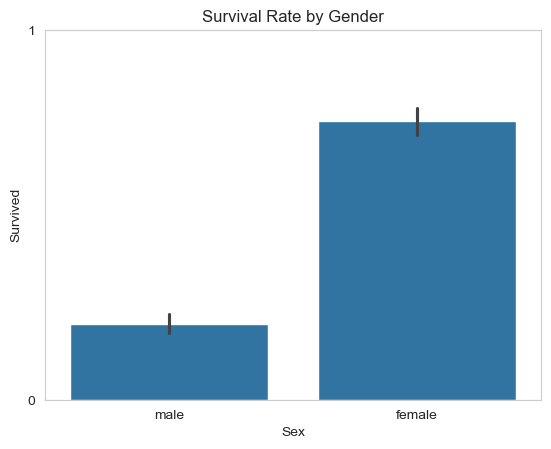

In [49]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Sex', y='Survived', data=df)
plt.ylim(0,1) 
plt.title('Survival Rate by Gender')
plt.show()

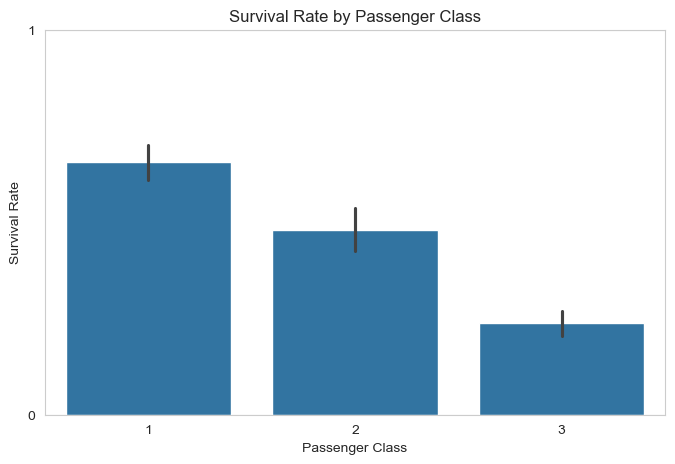

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x='Pclass', y='Survived', data=df, order=[1,2,3])

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0,1)

plt.show()

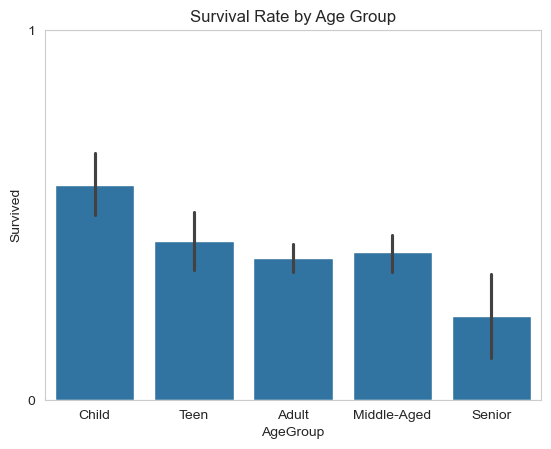

In [51]:
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.ylim(0,1)
plt.title('Survival Rate by Age Group')
plt.show()

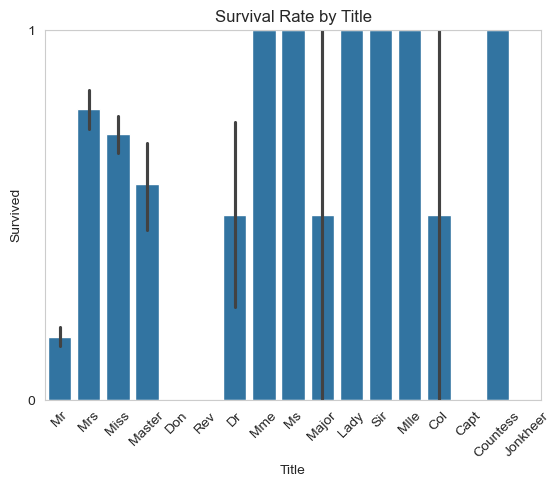

In [54]:
sns.barplot(x='Title', y='Survived', data=df)
plt.ylim(0,1)
plt.title('Survival Rate by Title')
plt.xticks(rotation=45)
plt.show()
     

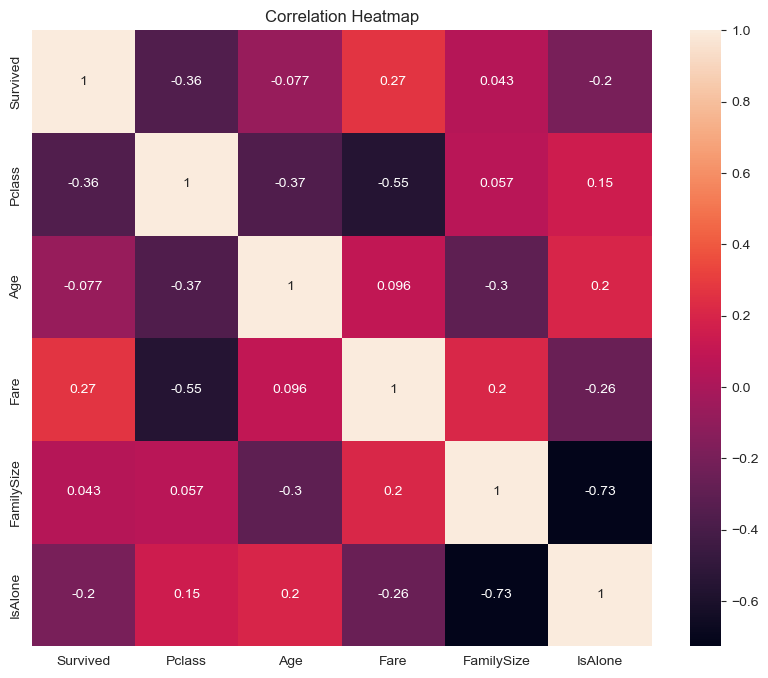

In [56]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['Survived','Pclass','Age','Fare','FamilySize','IsAlone']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()
     